# DOS(E_F) as a DFT Proxy for Superconducting Tendency
### Predicting the Density of States at the Fermi Level from Compositional Descriptors

---

**Project overview**

The density of states at the Fermi level, DOS(E_F), is a scalar quantity that only has a clear
physical meaning for metals (band gap = 0). It also enters directly into the McMillan/Allen-Dynes
picture of conventional superconductivity: the electron-phonon coupling constant λ scales with
`N(E_F)`, so materials with a large DOS(E_F) are, all else equal, better *candidates* for further
electron-phonon coupling calculations (they are not sufficient on their own — λ also depends on
phonon frequencies and the coupling matrix element — but DOS(E_F) is a cheap, DFT-derived
pre-screening signal).

**Pipeline**

1. Query the Materials Project **electronic structure** endpoint for GGA/GGA+U NSCF density-of-states
   objects, restricted to experimentally observed compounds (`theoretical=False`) with band gap = 0
   (metals) — real, ICSD-matched materials rather than purely DFT-predicted candidates.
2. Deduplicate to the lowest-energy polymorph per unique composition. Since MAGPIE features are
   purely compositional, every polymorph of the same formula would otherwise produce an (almost)
   identical feature vector, which inflates that composition's influence on Lasso feature selection
   and on cross-validation.
3. Classify each material's elemental family and periodic row, then take a stratified, capped sample
   across (family × crystal system) — this bounds the number of expensive per-material DOS lookups
   and keeps every group well represented for the grouped cross-validation later.
4. Extract DOS(E_F) by interpolating each compound's full DOS at its Fermi energy.
5. Featurize compositions with MAGPIE descriptors (via matminer) plus a one-hot crystal-system indicator.
6. Train a Random Forest regressor to predict DOS(E_F).
7. Use Lasso to identify which descriptors carry predictive weight.
8. Evaluate generalization with `GroupKFold` grouped by (a) elemental family
   (transition metal / alkaline earth / rare earth / ...) and (b) periodic row — i.e. does the model
   extrapolate to *new* elemental chemistries, or is it only interpolating within families it has
   already seen? Visualize the comparison as a bar chart.
9. Check for plain overfitting (independent of the elemental-generalization question above) with a
   random 80/20 train/test split, a predicted-vs-actual parity plot, and a train-vs-test RMSE
   comparison.
10. (Optional) Violin plots of DOS(E_F) by crystal system, log-scaled since DOS(E_F) is heavily
    right-skewed, to flag favorable structural symmetries.

**Requirements to run this notebook**

- A free Materials Project API key. Create a `.env` file next to this notebook containing:
  `MP_API_KEY=your_key_here` (get a key at https://next-gen.materialsproject.org/api). Add `.env` to
  your `.gitignore` so it's never committed.
- Packages: `mp-api`, `pymatgen`, `matminer`, `scikit-learn`, `pandas`, `numpy`, `matplotlib`,
  `seaborn`, `tqdm`, `python-dotenv`.
- Internet access to `api.materialsproject.org`.

This notebook was not executed in the authoring environment (no network access to the Materials
Project API there) — run it locally / on a machine with an API key and internet access. Cell-by-cell
comments explain the reasoning behind each design decision so you can adapt thresholds, model
hyperparameters, or grouping definitions as needed.


---
## Part 1 — Setup

In [13]:
# Imports
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from dotenv import load_dotenv

from mp_api.client import MPRester
from pymatgen.core import Element

from matminer.featurizers.composition import ElementProperty

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GroupKFold, KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Imports OK")

Imports OK


In [14]:
# Materials Project API key, loaded from a .env file
# 1. pip install python-dotenv
# 2. Create a file named ".env" in this notebook's directory containing:
#      MP_API_KEY=your_key_here
# 3. Add ".env" to your .gitignore so the key never gets committed.

load_dotenv()  # reads .env in the current working directory and loads it into os.environ

MP_API_KEY = os.environ.get("MP_API_KEY", "")
if not MP_API_KEY:
    raise ValueError(
        "MP_API_KEY not found. Make sure you have a .env file in the notebook's "
        "directory containing a line like: MP_API_KEY=your_key_here"
    )

---
## Part 2 — Query experimentally observed metals

Only metals have a physically meaningful DOS(E_F): for an insulator or semiconductor the Fermi level
sits in the gap, so DOS(E_F) is either exactly zero or an artifact of the DFT smearing scheme, not a
real physical quantity. We filter to `band_gap == 0` (metals) at the summary-search stage, before
doing the more expensive per-material DOS lookups.

We restrict to `theoretical=False` — experimentally observed, ICSD-matched materials — rather than
`is_stable=True`. This is a deliberate choice: it keeps the dataset to real, synthesized compounds
(the kind of material a follow-up electron-phonon coupling study would actually target), including
ones that are metastable relative to DFT's predicted hull, rather than every DFT-predicted candidate
regardless of whether it has ever been made.

In [15]:
# Cache the raw query result to disk so re-running this notebook doesn't hit the
# Materials Project API again. Structure objects aren't plain-JSON-serializable, so we
# use pickle here. Delete the cache file to force a fresh query (e.g. if you change the
# filter criteria below).
QUERY_CACHE_PATH = "metals_query_cache.pkl"

if os.path.exists(QUERY_CACHE_PATH):
    df_all = pd.read_pickle(QUERY_CACHE_PATH)
    print(f"Loaded cached query results from {QUERY_CACHE_PATH}: {len(df_all)} materials "
          f"(delete this file to force a fresh query)")
else:
    FIELDS = [
        "material_id", "formula_pretty", "structure", "band_gap",
        "symmetry", "theoretical", "energy_above_hull",
    ]
    with MPRester(MP_API_KEY) as mpr:
        docs = mpr.materials.summary.search(
            band_gap=(0, 0), theoretical=False, fields=FIELDS,
        )
    df_all = pd.DataFrame([{
        "material_id": str(d.material_id),
        "formula": d.formula_pretty,
        "structure": d.structure,
        "crystal_system": d.symmetry.crystal_system.value if d.symmetry else None,
        "energy_above_hull": d.energy_above_hull,
    } for d in docs])
    df_all.to_pickle(QUERY_CACHE_PATH)
    print(f"Queried {len(df_all)} experimentally observed metals, cached to {QUERY_CACHE_PATH}")

Loaded cached query results from metals_query_cache.pkl: 19711 materials (delete this file to force a fresh query)


---
## Part 3 — Deduplicate to the lowest-energy polymorph per composition

MAGPIE descriptors are purely compositional — they don't see structure at all, so every polymorph of
the same formula (different space group, different calculation) produces an **identical** feature
vector. Leaving duplicates in would let a single composition contribute several (near-)identical rows
to Lasso feature selection and to cross-validation, silently inflating its influence and understating
how many genuinely independent compositions the model has actually been evaluated on — a real problem
for feature selection specifically, since a duplicated composition's descriptor values get correctly
selected or zeroed out repeatedly rather than counted once.

We keep only the lowest-`energy_above_hull` entry per unique formula: the polymorph closest to (or on)
the hull is the one most likely to correspond to what was actually observed experimentally, of the
polymorphs MP has calculated for that composition.

In [16]:
before = len(df_all)

df_all = (
    df_all
    .sort_values("energy_above_hull", na_position="last")
    .drop_duplicates(subset="formula", keep="first")
    .reset_index(drop=True)
)

print(f"Deduplicated by composition: {before} -> {len(df_all)} unique formulas "
      f"(kept lowest energy_above_hull polymorph per formula)")

Deduplicated by composition: 19711 -> 19711 unique formulas (kept lowest energy_above_hull polymorph per formula)


---
## Part 4 — Elemental family and period labels

Before deciding how many materials to actually pull full DOS objects for, we classify each one so we
can (a) sample in a way that keeps every group well represented and (b) reuse the same labels later
as `GroupKFold` groups. Each material's group is defined from its **dominant element** — the element
with the highest atomic fraction in the composition — using pymatgen's built-in element-category
flags for the family, and the element's periodic row for the period.

In [17]:
def dominant_element(struct):
    """Element with the largest atomic fraction in the composition."""
    frac = struct.composition.get_el_amt_dict()
    return max(frac, key=frac.get)


def elemental_family(el_symbol):
    """Coarse elemental family used for GroupKFold grouping."""
    el = Element(el_symbol)
    # pymatgen renamed this property at some point (is_rare_earth_metal -> is_rare_earth);
    # check both so this works across pymatgen versions.
    is_rare_earth = getattr(el, "is_rare_earth", None)
    if is_rare_earth is None:
        is_rare_earth = getattr(el, "is_rare_earth_metal", el.is_lanthanoid or el.is_actinoid)
    if is_rare_earth:
        return "rare_earth"
    if el.is_alkaline:
        return "alkaline_earth"
    if el.is_alkali:
        return "alkali"
    if el.is_transition_metal:
        return "transition_metal"
    if el.is_post_transition_metal:
        return "post_transition_metal"
    if el.is_metalloid:
        return "metalloid"
    return "other"


df_all["dominant_element"] = df_all["structure"].apply(dominant_element)
df_all["family"] = df_all["dominant_element"].apply(elemental_family)
df_all["period"] = df_all["dominant_element"].apply(lambda e: Element(e).row)

print("Materials per elemental family:")
print(df_all["family"].value_counts())
print("\nMaterials per (family, crystal system):")
print(df_all.groupby(["family", "crystal_system"]).size())

Materials per elemental family:
family
transition_metal         5741
other                    5410
rare_earth               3299
metalloid                2289
post_transition_metal    1790
alkaline_earth            764
alkali                    418
Name: count, dtype: int64

Materials per (family, crystal system):
family                 crystal_system
alkali                 Cubic              127
                       Hexagonal           66
                       Monoclinic          22
                       Orthorhombic        86
                       Tetragonal          63
                       Triclinic            5
                       Trigonal            49
alkaline_earth         Cubic              222
                       Hexagonal          153
                       Monoclinic          40
                       Orthorhombic       173
                       Tetragonal         140
                       Triclinic            3
                       Trigonal            33
me

---
## Part 5 — Stratified, capped sample

Rather than fetching DOS objects for every remaining metal in `df_all`, we take a stratified sample
capped at `CAP_PER_STRATUM` materials per (family × crystal system) combination. This bounds the
number of expensive lookups in Part 6 to a small, predictable multiple of the number of strata, and
ensures every group has comparable representation going into the `GroupKFold` evaluation later.

This is a deliberate design choice, not a shortcut: it trades "reflects the natural distribution over
families" for "every family is evaluable," which is what the generalization question in Part 8
actually needs. Raise `CAP_PER_STRATUM` if you want a larger dataset and can tolerate a longer Part 6
runtime; lower it to iterate faster while developing the rest of the pipeline. With the
experimentally-observed-only, deduplicated population from Parts 2–3, the total sample size will be
noticeably smaller than pulling from the full stable-or-theoretical population, so it's worth checking
the printed count below before deciding whether to raise the cap.

In [18]:
CAP_PER_STRATUM = 300
RANDOM_STATE = 42

df = (
    df_all
    .groupby(["family", "crystal_system"], group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), CAP_PER_STRATUM), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Sampled {len(df)} / {len(df_all)} metals "
      f"(capped at {CAP_PER_STRATUM} per family x crystal-system stratum)")
print(df.groupby("family").size())

Sampled 8922 / 19711 metals (capped at 300 per family x crystal-system stratum)
family
alkali                    418
alkaline_earth            764
metalloid                1258
other                    2073
post_transition_metal    1308
rare_earth               1430
transition_metal         1671
dtype: int64


---
## Part 6 — Fetch DOS objects and extract DOS(E_F)

For each sampled metal, we pull the computed `CompleteDos` object (GGA or GGA+U NSCF, as stored by
the Materials Project's electronic-structure endpoint) and linearly interpolate the **total** density
of states at the Fermi energy reported for that calculation. `get_dos_by_material_id` does not load
atom/orbital-projected DOS unless asked, so each call is already reasonably light.

We fetch in parallel with a thread pool (these are network-bound calls). Each worker thread gets
its own `MPRester` instance (created lazily on first use, one per thread rather than one per material)
with `mute_progress_bars=True` — sharing a single client across threads is unsafe for this specific
call, since it lazily registers a cached Delta table on first use and concurrent threads can race to
register it. Muting progress bars also avoids rendering one widget per material, which would otherwise
bloat the saved notebook enormously with no useful information. The `try/finally` ensures the executor
shuts down cleanly (cancelling any still-pending lookups) even if the cell is interrupted or a lookup
raises, rather than leaving background threads running after the cell appears to have stopped -
that's what produces a flood of socket errors if you interrupt this cell mid-run.

from mp_api.client import MPRestError
import threading

# MPRester is not safe to share across threads for this particular call: get_dos_by_material_id
# registers a cached "total_dos" Delta table lazily on first use, and if two threads call it at
# the same moment on a *shared* client, both can see "not yet registered" and race to register it,
# raising DeltaError: "table already exists". Giving each worker THREAD its own client (created
# lazily, once per thread, via threading.local()) avoids the race without losing the parallelism -
# ThreadPoolExecutor reuses its 8 worker threads across all submitted tasks, so this creates only
# 8 MPRester instances total, not one per material.
_thread_local = threading.local()

def get_dos_at_fermi(mid):
    if not hasattr(_thread_local, "mpr"):
        _thread_local.mpr = MPRester(MP_API_KEY, mute_progress_bars=True)
    mpr = _thread_local.mpr
    # MPRestError here means no NSCF DOS calculation exists for this material -
    # a real, expected condition (not every metal in MP has electronic structure
    # data computed), not a bug. We skip it rather than let one missing entry
    # kill the whole batch. Any other exception type still propagates normally.
    try:
        dos = mpr.get_dos_by_material_id(mid)
    except MPRestError:
        return mid, None
    densities = dos.get_densities()          # spin channels already summed
    return mid, float(np.interp(dos.efermi, dos.energies, densities))


# Incremental cache, keyed by material_id, stored as plain JSON. Unlike caching the whole
# sampled dataframe, this survives changing CAP_PER_STRATUM or RANDOM_STATE later - only
# material_ids not already in the cache get fetched, and everything already looked up
# (across any previous run) is reused for free.
DOS_CACHE_PATH = "dos_ef_cache.json"

if os.path.exists(DOS_CACHE_PATH):
    with open(DOS_CACHE_PATH) as f:
        dos_ef_map = json.load(f)
    print(f"Loaded {len(dos_ef_map)} cached DOS(E_F) values from {DOS_CACHE_PATH}")
else:
    dos_ef_map = {}

to_fetch = [mid for mid in df["material_id"] if mid not in dos_ef_map]
print(f"{len(df) - len(to_fetch)} already cached, fetching {len(to_fetch)} new materials...")

if to_fetch:
    executor = ThreadPoolExecutor(max_workers=8)
    try:
        futures = [executor.submit(get_dos_at_fermi, mid) for mid in to_fetch]
        for future in tqdm(as_completed(futures), total=len(futures), desc="Fetching DOS(E_F)"):
            mid, dos_ef = future.result()
            dos_ef_map[mid] = dos_ef
    finally:
        executor.shutdown(wait=True, cancel_futures=True)

    with open(DOS_CACHE_PATH, "w") as f:
        json.dump(dos_ef_map, f)
    print(f"Saved {len(dos_ef_map)} total cached DOS(E_F) values to {DOS_CACHE_PATH}")

df["dos_ef"] = df["material_id"].map(dos_ef_map)
n_ok = df["dos_ef"].notna().sum()
print(f"DOS(E_F) retrieved for {n_ok} / {len(df)} materials "
      f"({len(df) - n_ok} skipped: no NSCF DOS calculation available).")

In [19]:
import json
import pandas as pd
from pymatgen.core import Element

# --- Load cached query result (structures + metadata) instead of re-querying ---
df_all = pd.read_pickle("metals_query_cache.pkl")

# --- Part 3 (dedup) and Part 4 (family/period) still need to run - they're
#     cheap, local, no network calls, so redoing them here is essentially free ---
df_all = (
    df_all
    .sort_values("energy_above_hull", na_position="last")
    .drop_duplicates(subset="formula", keep="first")
    .reset_index(drop=True)
)

def dominant_element(struct):
    frac = struct.composition.get_el_amt_dict()
    return max(frac, key=frac.get)

def elemental_family(el_symbol):
    el = Element(el_symbol)
    is_rare_earth = getattr(el, "is_rare_earth", None)
    if is_rare_earth is None:
        is_rare_earth = getattr(el, "is_rare_earth_metal", el.is_lanthanoid or el.is_actinoid)
    if is_rare_earth:
        return "rare_earth"
    if el.is_alkaline:
        return "alkaline_earth"
    if el.is_alkali:
        return "alkali"
    if el.is_transition_metal:
        return "transition_metal"
    if el.is_post_transition_metal:
        return "post_transition_metal"
    if el.is_metalloid:
        return "metalloid"
    return "other"

df_all["dominant_element"] = df_all["structure"].apply(dominant_element)
df_all["family"] = df_all["dominant_element"].apply(elemental_family)
df_all["period"] = df_all["dominant_element"].apply(lambda e: Element(e).row)

# --- Load cached DOS(E_F) values and restrict df to materials you actually have data for ---
with open("dos_ef_cache.json") as f:
    dos_ef_map = json.load(f)

df = df_all[df_all["material_id"].isin(dos_ef_map.keys())].reset_index(drop=True)
df["dos_ef"] = df["material_id"].map(dos_ef_map)
df = df[df["dos_ef"].notna()].reset_index(drop=True)

print(f"Recovered {len(df)} materials with cached DOS(E_F) values - "
      f"run Part 7 (featurization) on this df, then Part 8 onward as normal.")

Recovered 3256 materials with cached DOS(E_F) values - run Part 7 (featurization) on this df, then Part 8 onward as normal.


---
## Part 7 — Featurization: MAGPIE compositional descriptors + crystal system

We convert each structure to a `Composition` and run matminer's MAGPIE `ElementProperty` featurizer
(the same composition-based feature set used in Ward et al. 2016), then add the crystal system as a
one-hot indicator so the model can also use coarse structural information without needing full
structural descriptors. `family` and `period` (computed in Part 4) ride along unchanged for use as
`GroupKFold` groups.

In [20]:
df["composition"] = df["structure"].apply(lambda s: s.composition)

ep_feat = ElementProperty.from_preset("magpie")
magpie_cols = ep_feat.feature_labels()

df_feat = ep_feat.featurize_dataframe(df, col_id="composition", ignore_errors=True)

xtal_dummies = pd.get_dummies(df_feat["crystal_system"], prefix="xtal")

X_full = pd.concat([df_feat[magpie_cols], xtal_dummies], axis=1)
y_full = df_feat["dos_ef"]

# Drop rows with missing features or missing target (failed featurization, if any)
mask = X_full.notna().all(axis=1) & y_full.notna()
X = X_full[mask].reset_index(drop=True)
y = y_full[mask].reset_index(drop=True)
meta = df_feat.loc[mask, ["material_id", "formula", "crystal_system", "family", "period"]].reset_index(drop=True)

print(f"Final modeling set: {len(X)} materials, {X.shape[1]} features "
      f"({len(magpie_cols)} MAGPIE + {len(xtal_dummies.columns)} crystal-system indicators)")

ElementProperty:   0%|          | 0/3256 [00:00<?, ?it/s]

Final modeling set: 3256 materials, 139 features (132 MAGPIE + 7 crystal-system indicators)


---
## Part 8 — Random Forest baseline + GroupKFold cross-validation

We first fit a Random Forest with ordinary (ungrouped) K-fold CV as a baseline — this is the
"interpolation within known families" regime, since a given elemental family will typically appear
in both the train and test fold. We then repeat the evaluation with `GroupKFold` grouped by (a)
elemental family and (b) period, which forces each held-out fold to contain elemental chemistries
the model did not train on. A large gap between the ungrouped and grouped scores is evidence that
the model is mostly interpolating rather than learning transferable composition→DOS(E_F) physics.

In [21]:
rf = RandomForestRegressor(n_estimators=300, max_features="sqrt", random_state=42, n_jobs=-1)

# --- Baseline: ordinary KFold (no grouping constraint) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_kfold = -cross_val_score(rf, X, y, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)
print(f"Ordinary 5-fold CV MAE: {mae_kfold.mean():.4f} +/- {mae_kfold.std():.4f}")

Ordinary 5-fold CV MAE: 6.4667 +/- 0.2579


In [22]:
def run_group_kfold(X, y, groups, label, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    mae_scores, r2_scores = [], []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
        rf_fold = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                         random_state=42, n_jobs=-1)
        rf_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = rf_fold.predict(X.iloc[test_idx])
        mae = mean_absolute_error(y.iloc[test_idx], pred)
        r2 = r2_score(y.iloc[test_idx], pred)
        mae_scores.append(mae)
        r2_scores.append(r2)
        held_out = sorted(pd.unique(groups.iloc[test_idx]))
        print(f"[{label}] Fold {fold}: held-out groups={held_out} "
              f"MAE={mae:.4f} R2={r2:.3f}")
    print(f"\n[{label}] Mean MAE = {np.mean(mae_scores):.4f} +/- {np.std(mae_scores):.4f}, "
          f"Mean R2 = {np.mean(r2_scores):.3f}\n")
    return mae_scores, r2_scores


mae_family, r2_family = run_group_kfold(X, y, meta["family"], "grouped by elemental family")

[grouped by elemental family] Fold 0: held-out groups=['other'] MAE=12.3184 R2=-0.002
[grouped by elemental family] Fold 1: held-out groups=['transition_metal'] MAE=6.7281 R2=0.212
[grouped by elemental family] Fold 2: held-out groups=['alkali', 'rare_earth'] MAE=7.7677 R2=0.083
[grouped by elemental family] Fold 3: held-out groups=['metalloid'] MAE=6.7003 R2=0.280
[grouped by elemental family] Fold 4: held-out groups=['alkaline_earth', 'post_transition_metal'] MAE=5.1559 R2=0.209

[grouped by elemental family] Mean MAE = 7.7341 +/- 2.4391, Mean R2 = 0.156



In [23]:
mae_period, r2_period = run_group_kfold(X, y, meta["period"], "grouped by period")

[grouped by period] Fold 0: held-out groups=[np.int64(4)] MAE=6.7608 R2=0.205
[grouped by period] Fold 1: held-out groups=[np.int64(2)] MAE=9.9825 R2=0.125
[grouped by period] Fold 2: held-out groups=[np.int64(6)] MAE=6.8391 R2=0.174
[grouped by period] Fold 3: held-out groups=[np.int64(1), np.int64(3)] MAE=6.4420 R2=0.236
[grouped by period] Fold 4: held-out groups=[np.int64(5), np.int64(7)] MAE=6.8426 R2=0.323

[grouped by period] Mean MAE = 7.3734 +/- 1.3128, Mean R2 = 0.213



**Comparison.** The ordinary K-fold MAE above is the "easy" number — it very likely underestimates
error on genuinely novel chemistry, since related elements tend to land in both train and test folds
by chance. Compare it directly to the family- and period-grouped MAEs computed above: a substantially
higher grouped MAE indicates the model is leaning on family-specific patterns rather than a
transferable composition→DOS(E_F) relationship, which matters if the eventual goal is screening *new*
candidate chemistries for electron-phonon follow-up calculations rather than re-scoring compounds
similar to ones already in the training set.

---
## Part 9 — Visualizing the CV comparison

The three MAE numbers above (ordinary K-fold, GroupKFold-by-family, GroupKFold-by-period) are the
actual answer to "does this generalize," but as printed floats scattered across three cells they're
easy to under-weight. Plotting them side by side makes the generalization gap immediate: bars for the
two grouped schemes noticeably taller than the ordinary K-fold bar is direct visual evidence that the
model leans on having already seen a given elemental family, rather than learning composition→DOS(E_F)
physics that transfers to new chemistries.

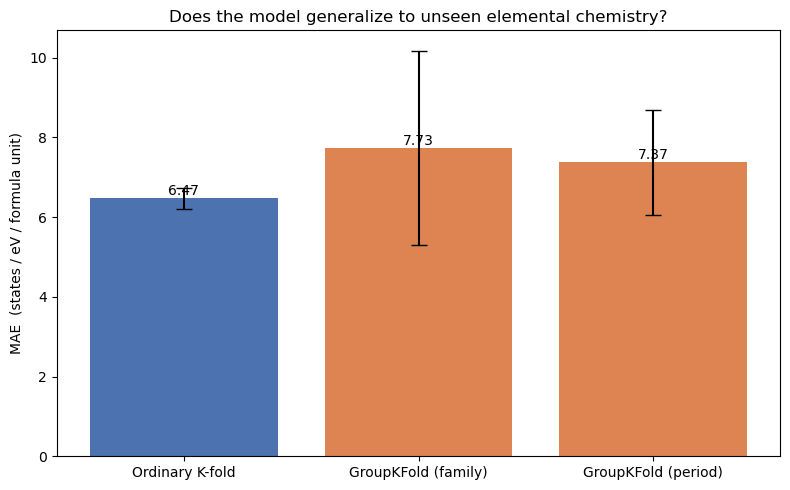

<Figure size 640x480 with 0 Axes>

In [25]:
cv_comparison = pd.DataFrame({
    "scheme": ["Ordinary K-fold", "GroupKFold (family)", "GroupKFold (period)"],
    "mean_mae": [mae_kfold.mean(), np.mean(mae_family), np.mean(mae_period)],
    "std_mae":  [mae_kfold.std(),  np.std(mae_family),  np.std(mae_period)],
})

plt.figure(figsize=(8, 5))
bars = plt.bar(cv_comparison["scheme"], cv_comparison["mean_mae"],
               yerr=cv_comparison["std_mae"], capsize=6,
               color=["#4C72B0", "#DD8452", "#DD8452"])
plt.ylabel("MAE  (states / eV / formula unit)")
plt.title("Does the model generalize to unseen elemental chemistry?")
for bar, val in zip(bars, cv_comparison["mean_mae"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}",
              ha="center", va="bottom")
plt.tight_layout()
plt.show()
plt.savefig("figures/fig1.png", dpi=300)

---
## Part 10 — Held-out train/test split

As a second, complementary check, we also fit on a simple random 80/20 train/test split (not grouped
by family — this is deliberately the "easy," interpolation-friendly split) and compare train vs. test
RMSE directly. A large train/test gap here is the classic overfitting signature: if the model fits the
training data far better than it predicts held-out points even under this easy random split, that's a
capacity/overfitting problem independent of the elemental-generalization question Parts 8–9 address.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_tt = RandomForestRegressor(n_estimators=300, max_features="sqrt", random_state=42, n_jobs=-1)
rf_tt.fit(X_train, y_train)

pred_train = rf_tt.predict(X_train)
pred_test = rf_tt.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"Train RMSE: {rmse_train:.4f}  (n={len(X_train)})")
print(f"Test RMSE:  {rmse_test:.4f}  (n={len(X_test)})")
print(f"Test/train RMSE ratio: {rmse_test / rmse_train:.2f}x")

Train RMSE: 4.8999  (n=2604)
Test RMSE:  10.5539  (n=652)
Test/train RMSE ratio: 2.15x


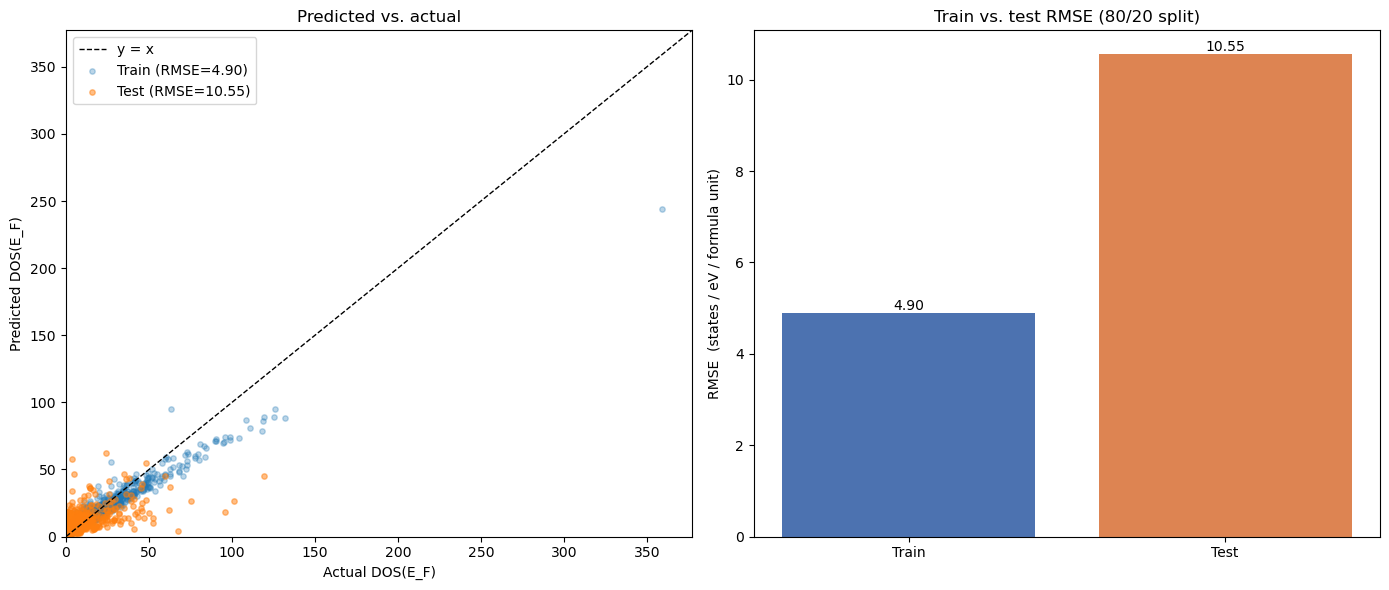

<Figure size 640x480 with 0 Axes>

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Parity plot: predicted vs actual, train and test overlaid ---
ax = axes[0]
lims = [0, max(y_train.max(), y_test.max(), pred_train.max(), pred_test.max()) * 1.05]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x")
ax.scatter(y_train, pred_train, alpha=0.3, s=15, label=f"Train (RMSE={rmse_train:.2f})")
ax.scatter(y_test, pred_test, alpha=0.5, s=15, label=f"Test (RMSE={rmse_test:.2f})")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual DOS(E_F)")
ax.set_ylabel("Predicted DOS(E_F)")
ax.set_title("Predicted vs. actual")
ax.legend()

# --- Train vs test RMSE bar chart ---
ax = axes[1]
bars = ax.bar(["Train", "Test"], [rmse_train, rmse_test], color=["#4C72B0", "#DD8452"])
for bar, val in zip(bars, [rmse_train, rmse_test]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}",
            ha="center", va="bottom")
ax.set_ylabel("RMSE  (states / eV / formula unit)")
ax.set_title("Train vs. test RMSE (80/20 split)")

plt.tight_layout()
plt.show()
plt.savefig("figures/fig2.png", dpi=300)

---
## Part 11 — Lasso feature selection

We standardize the feature matrix and fit `LassoCV` (5-fold CV over a path of `alpha` values) to see
which MAGPIE descriptors and crystal-system indicators actually carry predictive weight for
DOS(E_F), versus which are shrunk to exactly zero. Deduplicating by composition in Part 3 matters
specifically here: without it, a handful of heavily-polymorphed compositions would otherwise appear
many times over with identical MAGPIE values, distorting which descriptors look predictive.

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1).fit(X_scaled, y)

coef = pd.Series(lasso.coef_, index=X.columns)
nonzero = coef[coef != 0].reindex(coef[coef != 0].abs().sort_values(ascending=False).index)

print(f"Selected alpha (LassoCV): {lasso.alpha_:.5f}")
print(f"Lasso retained {len(nonzero)} / {len(coef)} features as nonzero.\n")
print("Top 20 features by |coefficient|:")
nonzero.head(20)

Selected alpha (LassoCV): 0.07583
Lasso retained 67 / 139 features as nonzero.

Top 20 features by |coefficient|:


MagpieData range GSbandgap           3.799903
MagpieData mean Electronegativity    3.027806
MagpieData avg_dev GSbandgap        -2.419699
MagpieData mean SpaceGroupNumber    -2.209152
MagpieData avg_dev NfUnfilled        2.088048
MagpieData mean MeltingT            -1.986298
MagpieData mode SpaceGroupNumber     1.970685
MagpieData avg_dev CovalentRadius   -1.685867
MagpieData mean GSmagmom             1.623433
MagpieData mode NdUnfilled           1.551318
MagpieData avg_dev NpValence        -1.501948
MagpieData mode NpValence            1.501862
MagpieData avg_dev GSvolume_pa       1.459910
MagpieData maximum MeltingT          1.430841
MagpieData mean GSbandgap           -1.386518
MagpieData range NUnfilled           1.247454
MagpieData range SpaceGroupNumber    1.191631
MagpieData maximum NdUnfilled        1.175010
MagpieData minimum Row               0.978172
MagpieData maximum NValence         -0.908020
dtype: float64

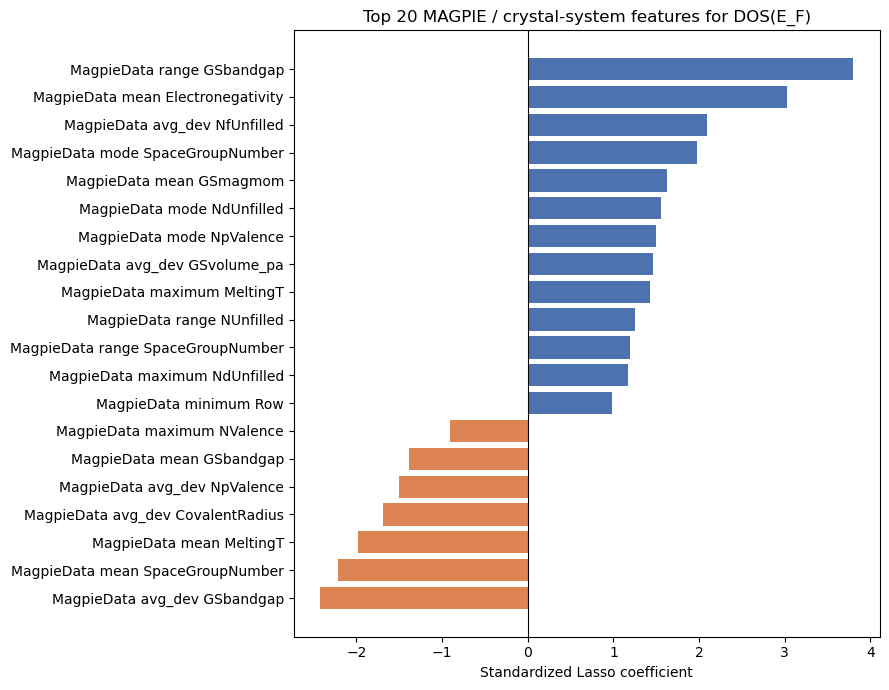

<Figure size 640x480 with 0 Axes>

In [30]:
top_n = nonzero.head(20).sort_values()   # ascending so barh reads largest-at-top

plt.figure(figsize=(9, 7))
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in top_n.values]
plt.barh(top_n.index, top_n.values, color=colors)
plt.xlabel("Standardized Lasso coefficient")
plt.title("Top 20 MAGPIE / crystal-system features for DOS(E_F)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
plt.savefig("figures/fig3.png", dpi=300)

---
## Part 12 (optional) — DOS(E_F) by crystal system

A quick visual check for whether particular crystal symmetries are systematically associated with
higher DOS(E_F) — a coarse, cheap signal for which structural families might be worth prioritizing
in a follow-up electron-phonon coupling screen.

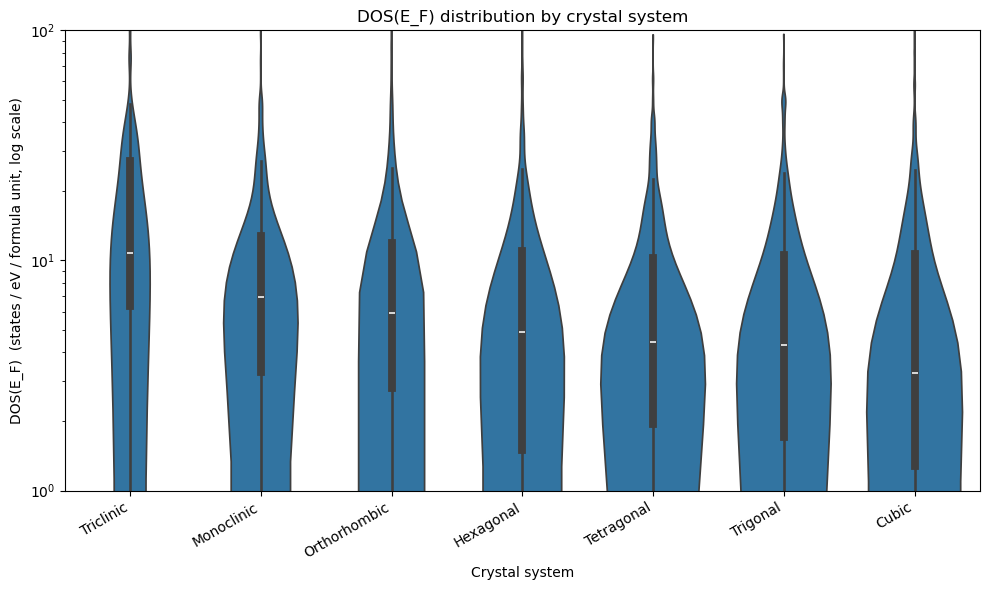

<Figure size 640x480 with 0 Axes>

In [31]:
plot_df = meta.copy()
plot_df["dos_ef"] = y.values

order = plot_df.groupby("crystal_system")["dos_ef"].median().sort_values(ascending=False).index

# DOS(E_F) is strictly positive and heavily right-skewed (a handful of large-DOS outliers,
# e.g. flat-band rare-earth compounds, alongside a bulk of modest values) - on a linear y-axis
# a violin plot like this collapses into a thin sliver near zero with a few needle-thin whiskers.
# Log-scaling the y-axis is what actually lets the shape comparison across crystal systems work.
#assert (plot_df["dos_ef"] > 0).all(), "log scale requires strictly positive DOS(E_F) values"

plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="crystal_system", y="dos_ef", order=order, cut=0)
plt.ylabel("DOS(E_F)  (states / eV / formula unit, log scale)")
plt.xlabel("Crystal system")
plt.yscale("log")
plt.ylim(bottom=1e-0, top=1e2)  # avoid extreme outliers dominating the y-axis
plt.title("DOS(E_F) distribution by crystal system")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("figures/fig4.png", dpi=300)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_train = mean_absolute_error(y_train, pred_train)
mae_test  = mean_absolute_error(y_test, pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

r2_train = r2_score(y_train, pred_train)
r2_test  = r2_score(y_test, pred_test)

print(f"{'Metric':<35}{'Test set':<15}{'Train set (optional)':<20}")
print(f"{'MAE (states/eV/formula unit)':<35}{mae_test:<15.4f}{mae_train:<20.4f}")
print(f"{'RMSE (states/eV/formula unit)':<35}{rmse_test:<15.4f}{rmse_train:<20.4f}")
print(f"{'R2':<35}{r2_test:<15.4f}{r2_train:<20.4f}")

Metric                             Test set       Train set (optional)
MAE (states/eV/formula unit)       6.0501         2.4442              
RMSE (states/eV/formula unit)      10.5539        4.8999              
R2                                 0.3297         0.9043              


---
## Summary

- **Part 2** queries only experimentally observed metals (`theoretical=False`, `band_gap == 0`) —
  real, ICSD-matched materials rather than every DFT-predicted candidate.
- **Part 3** deduplicates to the lowest-energy polymorph per unique composition, which matters
  specifically because MAGPIE features are compositional-only: without this step, heavily-polymorphed
  compositions would be overrepresented in both Lasso feature selection and cross-validation.
- **Parts 4–5** classify elemental family/period and take a stratified, capped sample across
  (family × crystal system) *before* the expensive per-material DOS lookups, bounding runtime and
  keeping every group evaluable for the grouped CV in Part 8.
- **Part 6** extracts DOS(E_F) per material by interpolating the total DOS at the reported Fermi
  energy, fetched in parallel with a thread pool that shuts down cleanly on interruption.
- **Part 8** compares ordinary K-fold CV against `GroupKFold`-by-family and `GroupKFold`-by-period —
  the key diagnostic for whether the Random Forest generalizes to unseen elemental chemistry or is
  simply interpolating within families it has already seen.
- **Part 9** turns that comparison into a bar chart, so the generalization gap (or lack of one) is
  visible at a glance rather than requiring a scroll back through three printed numbers.
- **Part 10** adds a complementary, simpler diagnostic: a random 80/20 train/test split with a
  parity plot and a train-vs-test RMSE comparison, checking for plain overfitting independent of the
  elemental-generalization question Parts 8–9 address.
- **Part 11** (Lasso) narrows the MAGPIE + crystal-system descriptor set down to the subset that
  actually carries predictive weight for DOS(E_F), now shown as a feature-importance bar chart rather
  than a bare table.
- **Part 12**'s crystal-system violin plot uses a log y-axis, since DOS(E_F) is strictly positive and
  heavily right-skewed - on a linear scale the plot collapses into a sliver near zero and hides the
  actual shape comparison across crystal systems.
- DOS(E_F) is a *screening* proxy for superconducting tendency, not a substitute for it: it captures
  one factor (electronic density of states) in the McMillan/Allen-Dynes electron-phonon coupling
  picture, but says nothing about phonon frequencies or the electron-phonon matrix element.
  High-scoring candidates from this pipeline are best treated as a shortlist for actual
  electron-phonon coupling (e.g. DFPT / EPW) calculations, not as final Tc predictions.